## **Machine Learning Aplicado a las Finanzas** 🚀
### **Sesión 9: Boosting — XGBoost/LightGBM para Predicción**

Andrés C. Medina Sanhueza

Senior Data Scientist Engineer

anmedinas@gmail.com

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import (
    roc_auc_score, mean_squared_error, roc_curve
)
import xgboost as xgb
import lightgbm as lgb
import yfinance as yf
import warnings

sns.set_style("dark")
warnings.filterwarnings("ignore")
np.random.seed(42)
pd.set_option("display.float_format", "{:.4f}".format)

## 🚀 **`Motivación: De Bagging a Boosting`**

### Lo que ya sabemos (Sesión 8)

Random Forest promedia $B$ árboles **independientes** entrenados en paralelo sobre datasets bootstrap. La varianza del promedio es:

$$\text{Var}\left(\frac{1}{B}\sum_{b=1}^B \hat{f}_b(x)\right) = \rho\sigma^2 + \frac{1-\rho}{B}\sigma^2$$

Bagging + feature subsampling reducen $\rho$ (correlación entre árboles) y con eso la varianza del promedio, pero **no tocan el sesgo**: por linealidad de la esperanza, $\mathbb{E}\left[\frac{1}{B}\sum_b \hat{f}_b(x)\right] = \mathbb{E}[\hat{f}_b(x)]$ — el sesgo del ensemble es idéntico al de un árbol individual, sin importar cuántos promedies. En la configuración estándar de Random Forest (árboles crecidos sin restricción real de profundidad) esto no es un problema: cada árbol ya parte de sesgo bajo y varianza alta, justo el punto de partida que bagging necesita para funcionar bien. El caso patológico sería restringir artificialmente la profundidad de los árboles (introduciendo sesgo donde no lo había): ahí promediar mil copias decorrelacionadas de esos árboles sesgados sigue produciendo el mismo sesgo, porque bagging no tiene ningún mecanismo para corregirlo — a diferencia de boosting.

### La idea de Boosting

En lugar de entrenar $B$ árboles independientes y promediarlos, Boosting entrena árboles **secuencialmente**, donde cada árbol nuevo se enfoca en corregir los errores que el ensemble acumulado hasta ese punto todavía comete:

$$F_M(x) = \sum_{m=1}^{M} \nu \cdot h_m(x)$$

donde cada $h_m$ es un árbol "débil" (poca profundidad) ajustado a lo que le falta al modelo $F_{m-1}$, y $\nu$ (`learning_rate`) controla cuánto confiar en cada corrección individual.

| | Bagging / Random Forest | Boosting |
|---|---|---|
| Entrenamiento | Paralelo (árboles independientes) | Secuencial (cada árbol depende del anterior) |
| Objetivo principal | ↓ Varianza | ↓ Sesgo (y controla varianza vía regularización) |
| Riesgo de `n_estimators` alto | Ninguno — el error converge y se estabiliza | **Sobreajuste** — más rondas sin control pueden empeorar el error de test |
| Sensibilidad a outliers/ruido | Baja (el bootstrap diluye cada punto) | Más alta — se abordará en esta sesión |
| Extrapolación fuera del rango de train | No (particiones constantes por región) | Tampoco (misma limitación estructural) |

El resto de la sesión desarrolla el mecanismo (Gradient Boosting), dos implementaciones industriales (XGBoost, LightGBM), y las implicancias prácticas de esa tabla para aplicaciones financieras.

## 📉 **`Gradient Boosting: Descenso de Gradiente Funcional`**

### El truco de Friedman (2001)

Gradient Boosting trata el ajuste del modelo como una optimización numérica, pero en el **espacio de funciones** en vez del espacio de parámetros. Dada una función de pérdida diferenciable $L(y, F(x))$, el algoritmo construye $F_M$ de forma aditiva:

**Paso 0:** $F_0(x) = \arg\min_c \sum_i L(y_i, c)$ (una constante — para MSE, la media de $y$)

**Para $m = 1, \ldots, M$:**
1. Calcular los **pseudo-residuos** (el gradiente negativo de la pérdida respecto a las predicciones actuales):
$$r_{im} = -\left[\frac{\partial L(y_i, F(x_i))}{\partial F(x_i)}\right]_{F=F_{m-1}}$$
   Para pérdida cuadrática $L = \frac{1}{2}(y-F)^2$, esto es simplemente el **residuo ordinario**: $r_{im} = y_i - F_{m-1}(x_i)$.
2. Ajustar un árbol $h_m(x)$ para predecir esos pseudo-residuos
3. Actualizar: $F_m(x) = F_{m-1}(x) + \nu \cdot h_m(x)$

Cada árbol es "débil" (típicamente `max_depth` 2-6) — la fuerza predictiva viene de sumar muchos de ellos, cada uno dando un paso pequeño ($\nu$ chico) en la dirección que más reduce la pérdida.

La celda siguiente implementa estos 3 pasos manualmente sobre una función seno con ruido, para visualizar cómo la suma de árboles débiles converge a la función verdadera.

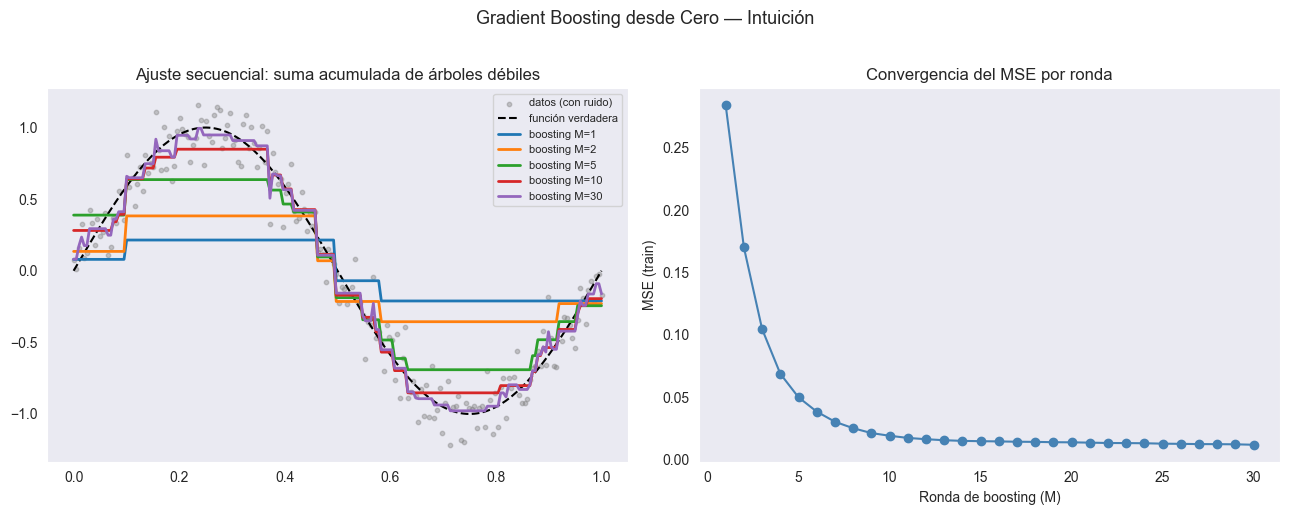

MSE ronda 1:  0.2840
MSE ronda 15: 0.0148
MSE ronda 30: 0.0120


In [2]:
np.random.seed(42)
x_gb = np.linspace(0, 1, 200).reshape(-1, 1)
y_true_gb = np.sin(2 * np.pi * x_gb).ravel()
y_gb = y_true_gb + np.random.normal(0, 0.15, len(x_gb))

lr_gb = 0.3
M_total = 30
snapshots = {1, 2, 5, 10, 30}
pred_gb = np.zeros(len(x_gb))
mse_by_round = []
snapshot_preds = {}

for m in range(1, M_total + 1):
    residual = y_gb - pred_gb                       # paso 1: pseudo-residuo (perdida cuadratica)
    stump = DecisionTreeRegressor(max_depth=2, random_state=42)
    stump.fit(x_gb, residual)                        # paso 2: ajustar arbol al residuo
    pred_gb = pred_gb + lr_gb * stump.predict(x_gb)   # paso 3: actualizar con shrinkage
    mse_by_round.append(mean_squared_error(y_gb, pred_gb))
    if m in snapshots:
        snapshot_preds[m] = pred_gb.copy()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(x_gb, y_gb, s=10, color="gray", alpha=0.4, label="datos (con ruido)")
axes[0].plot(x_gb, y_true_gb, "k--", lw=1.5, label="función verdadera")
for m, p in snapshot_preds.items():
    axes[0].plot(x_gb, p, lw=2, label=f"boosting M={m}")
axes[0].legend(fontsize=8)
axes[0].set_title("Ajuste secuencial: suma acumulada de árboles débiles")

axes[1].plot(range(1, M_total + 1), mse_by_round, "o-", color="steelblue")
axes[1].set_xlabel("Ronda de boosting (M)"); axes[1].set_ylabel("MSE (train)")
axes[1].set_title("Convergencia del MSE por ronda")

plt.suptitle("Gradient Boosting desde Cero — Intuición", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f"MSE ronda 1:  {mse_by_round[0]:.4f}")
print(f"MSE ronda 15: {mse_by_round[14]:.4f}")
print(f"MSE ronda 30: {mse_by_round[-1]:.4f}")

**Interpretación:** con $M=1$ el modelo apenas capta la forma general (un stump de profundidad 2 solo puede hacer un par de cortes). A medida que se agregan árboles, cada uno enfocado en el error que dejó el anterior, la suma acumulada converge rápidamente hacia la función seno verdadera — hacia $M=30$ prácticamente se superpone. El panel derecho muestra la caída del MSE de entrenamiento: rápida al principio, luego decreciente pero con retornos marginales. Este mismo mecanismo, con `DecisionTreeRegressor` reemplazado por árboles más profundos y agregando regularización explícita, es exactamente lo que hacen XGBoost y LightGBM internamente — la diferencia está en *cómo* de forma eficiente y regularizada se ajusta cada árbol.

## ⚡ **`XGBoost: Boosting Regularizado de Segundo Orden`**

### La función objetivo

XGBoost (Chen & Guestrin, 2016) modifica Gradient Boosting agregando un término de regularización explícito sobre la complejidad de cada árbol:

$$\mathcal{L}^{(m)} = \sum_{i=1}^n L\big(y_i,\, F_{m-1}(x_i) + h_m(x_i)\big) + \Omega(h_m), \qquad \Omega(h) = \gamma T + \frac{1}{2}\lambda \sum_{j=1}^T w_j^2$$

donde $T$ es el número de hojas del árbol y $w_j$ el valor (peso) de la hoja $j$. $\gamma$ penaliza tener muchas hojas (poda), $\lambda$ penaliza pesos de hoja grandes (similar a Ridge, hoja por hoja).

### Aproximación de segundo orden

En vez de usar solo el gradiente (como Gradient Boosting clásico), XGBoost expande la pérdida con una serie de Taylor de **segundo orden** alrededor de $F_{m-1}$, usando tanto el gradiente $g_i$ como el Hessiano $h_i$:

$$g_i = \frac{\partial L(y_i, F_{m-1}(x_i))}{\partial F_{m-1}(x_i)}, \qquad h_i = \frac{\partial^2 L(y_i, F_{m-1}(x_i))}{\partial F_{m-1}(x_i)^2}$$

Con esto, el peso óptimo de una hoja $j$ (que agrupa al conjunto de observaciones $I_j$) tiene forma cerrada:

$$w_j^{*} = -\frac{\sum_{i \in I_j} g_i}{\sum_{i \in I_j} h_i + \lambda}$$

Y la ganancia de un split candidato (usada para decidir dónde partir) es:

$$\text{Gain} = \frac{1}{2}\left[\frac{G_L^2}{H_L+\lambda} + \frac{G_R^2}{H_R+\lambda} - \frac{(G_L+G_R)^2}{H_L+H_R+\lambda}\right] - \gamma$$

**Lectura clave:** el denominador $H_j + \lambda$ actúa como un "amortiguador" — una hoja con pocas observaciones (Hessiano bajo) obtiene un peso más chico gracias a $\lambda$, evitando que el árbol memorice puntos aislados. Esto es la primera línea de defensa contra el sobreajuste que veremos más adelante en esta sesión.

Adicionalmente, XGBoost incorpora **shrinkage** ($\nu$ = `learning_rate`), **subsampling** de filas (`subsample`) y de columnas (`colsample_bytree`) — mecanismos que también existían en Random Forest, pero aquí cumplen el rol adicional de frenar el sobreajuste secuencial.

## 🍃 **`LightGBM: Crecimiento Leaf-Wise e Histogramas`**

LightGBM (Ke et al., 2017) resuelve el mismo objetivo regularizado que XGBoost, pero cambia dos decisiones de diseño clave:

1. **Crecimiento leaf-wise (vs level-wise):** XGBoost por defecto expande el árbol nivel por nivel (todos los nodos de una profundidad antes de pasar a la siguiente). LightGBM elige, en cada paso, la hoja con **mayor ganancia potencial** para partir, sin importar su profundidad. Esto produce árboles más profundos y asimétricos, y generalmente converge más rápido (menos árboles para el mismo error) — pero también sobreajusta más fácil en datasets chicos, por lo que `num_leaves` es el hiperparámetro de control de complejidad más importante (en vez de `max_depth`).
2. **Histogram-based split finding:** en vez de evaluar todos los valores únicos de un feature continuo como candidatos de split, LightGBM los agrupa en `bins` (histograma, tipicamente 255) y evalúa splits solo sobre los bordes de esos bins. Esto acelera dramáticamente el entrenamiento con pérdida mínima de precisión.
3. **GOSS (Gradient-based One-Side Sampling):** en vez de submuestrear filas al azar (como `subsample`), LightGBM retiene todas las observaciones con gradiente grande (las que el modelo peor predice) y solo submuestrea las de gradiente chico — la intuición es que las observaciones ya bien ajustadas aportan poca información adicional.

| | XGBoost | LightGBM | Random Forest |
|---|---|---|---|
| Crecimiento del árbol | Level-wise | **Leaf-wise** | Level-wise (sin poda por ganancia) |
| Control de complejidad | `max_depth`, $\gamma$, $\lambda$ | `num_leaves`, $\lambda$ | `max_depth`, `min_samples_leaf` |
| Velocidad en datasets grandes | Buena (histogramas desde v1.0) | **Muy alta** (histogramas + GOSS) | Buena (paraleliza árboles) |
| Riesgo de overfitting con hiperparámetros default | Moderado | **Alto** (leaf-wise es agresivo) | Bajo (bagging es autorregulado) |
| Requiere early stopping en producción | Sí | Sí | No (opcional) |

### Datos de trabajo

Para mantener continuidad con la sesión 8, usamos el mismo tipo de problema: **predicción de eventos de cola** (retorno del día siguiente en el percentil 5 más bajo — un proxy simple de "día de crash"). Este target tiene señal genuina (a diferencia de predecir la dirección diaria, que ronda el azar), lo que permite comparaciones honestas entre modelos.

Dividimos en **train / validation / test** (70% / 15% / 15%, respetando el orden temporal) porque tanto XGBoost como LightGBM necesitan un set de validación para *early stopping* — el mecanismo central para controlar el sobreajuste de boosting que exploramos a continuación.

In [3]:
TICKER = "AAPL"

raw = yf.download(TICKER, start="2015-01-01", end="2024-01-01", progress=False, auto_adjust=True)
if isinstance(raw.columns, pd.MultiIndex):
    raw.columns = raw.columns.get_level_values(0)

close = raw["Close"]
ret = close.pct_change()

feat = pd.DataFrame(index=raw.index)
feat["ret_lag1"] = ret.shift(1)
feat["ret_lag2"] = ret.shift(2)
feat["ret_lag5"] = ret.shift(1).rolling(5).sum()
feat["vol_20"]   = ret.shift(1).rolling(20).std() * np.sqrt(252)
feat["mom_10"]   = close.shift(1) / close.shift(11) - 1
delta = close.diff()
gain = delta.clip(lower=0).shift(1).rolling(14).mean()
loss = (-delta.clip(upper=0)).shift(1).rolling(14).mean()
feat["rsi_14"]   = 100 - 100 / (1 + gain / loss.replace(0, np.nan))
feat["vol_chg"]  = raw["Volume"].pct_change().shift(1)
feat["target"]   = (ret.shift(-1) <= ret.quantile(0.05)).astype(int)   # 1 = evento de cola
feat = feat.dropna()

FEATURES = ["ret_lag1", "ret_lag2", "ret_lag5", "vol_20", "mom_10", "rsi_14", "vol_chg"]

X = feat[FEATURES].values
y = feat["target"].values

split_tr = int(len(feat) * 0.70)
split_va = int(len(feat) * 0.85)
X_train, X_val, X_test = X[:split_tr], X[split_tr:split_va], X[split_va:]
y_train, y_val, y_test = y[:split_tr], y[split_tr:split_va], y[split_va:]

print(f"{TICKER}: {feat.shape[0]} obs | {len(FEATURES)} features")
print(f"Train: {len(y_train)} obs | Val: {len(y_val)} obs | Test: {len(y_test)} obs")
print(f"Tasa de eventos de cola — train: {y_train.mean():.2%} | val: {y_val.mean():.2%} | test: {y_test.mean():.2%}")

AAPL: 2243 obs | 7 features
Train: 1570 obs | Val: 336 obs | Test: 337 obs
Tasa de eventos de cola — train: 4.97% | val: 5.65% | test: 4.45%


## 🔧 **`Hiperparámetros e Overfitting: el Riesgo que RF no Tenía`**

| Hiperparámetro | Rol | Efecto al aumentar |
|---|---|---|
| `learning_rate` ($\nu$) | Tamaño del paso por árbol | ↓ overfitting pero requiere más `n_estimators` para converger |
| `n_estimators` + *early stopping* | Número de rondas de boosting | **A diferencia de RF, más rondas SÍ puede sobreajustar** — se controla deteniendo el entrenamiento cuando el error de validación deja de mejorar |
| `max_depth` (XGBoost) / `num_leaves` (LightGBM) | Complejidad de cada árbol débil | ↑ varianza por árbol — LightGBM es más sensible por su crecimiento leaf-wise |
| `subsample` / `colsample_bytree` | Fracción de filas/columnas por árbol | ↓ correlación entre árboles sucesivos, similar al rol de `max_features` en RF |
| `reg_lambda`, `reg_alpha` | Regularización L2 / L1 sobre los pesos de hoja | ↓ magnitud de las correcciones por hoja — amortigua outliers (ver sección de sensibilidad a ruido) |
| `min_child_weight` (XGBoost) / `min_data_in_leaf` (LightGBM) | Mínimo de "masa" (suma de Hessianos / observaciones) por hoja | Evita hojas creadas para memorizar 1-2 observaciones |

La celda siguiente entrena un único XGBoost con `learning_rate` relativamente alto y **sin** early stopping, evaluando el AUC de train y de validación a distintos números de rondas. Esto replica, con datos financieros reales, la curva de sesgo-varianza que vimos para árboles individuales en la sesión 8 — pero ahora el eje X es `n_estimators`, el hiperparámetro que en Random Forest era "gratis".

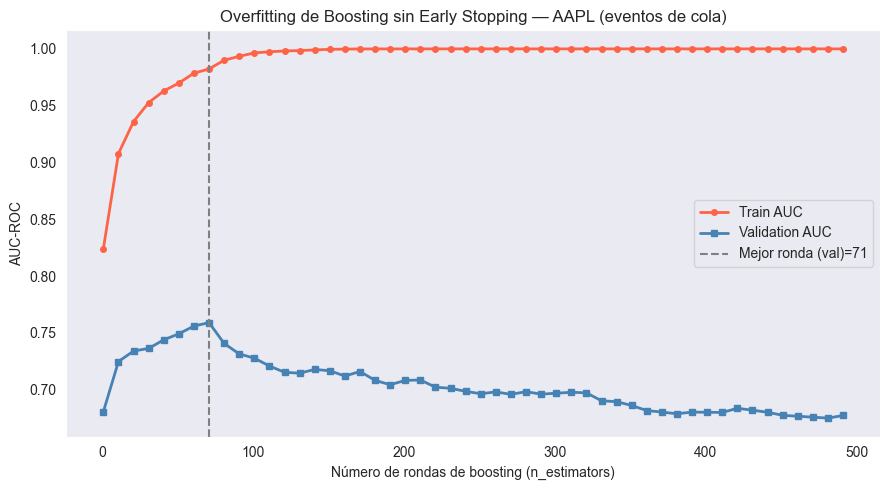

AUC train en la ronda final (500): 1.0000  (memorización casi perfecta)
AUC val en la mejor ronda (71): 0.7591
AUC val en la ronda final (500): 0.6774  (degradado respecto al óptimo)


In [4]:
xgb_overfit = xgb.XGBClassifier(n_estimators=500, learning_rate=0.1, max_depth=4, random_state=42)
xgb_overfit.fit(X_train, y_train)

rounds = list(range(1, 501, 10))
train_auc, val_auc = [], []
for r in rounds:
    p_tr = xgb_overfit.predict_proba(X_train, iteration_range=(0, r))[:, 1]
    p_va = xgb_overfit.predict_proba(X_val,   iteration_range=(0, r))[:, 1]
    train_auc.append(roc_auc_score(y_train, p_tr))
    val_auc.append(roc_auc_score(y_val, p_va))

best_round = rounds[int(np.argmax(val_auc))]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(rounds, train_auc, "o-", color="tomato", lw=2, ms=4, label="Train AUC")
ax.plot(rounds, val_auc, "s-", color="steelblue", lw=2, ms=4, label="Validation AUC")
ax.axvline(best_round, color="gray", ls="--", lw=1.5, label=f"Mejor ronda (val)={best_round}")
ax.set_xlabel("Número de rondas de boosting (n_estimators)")
ax.set_ylabel("AUC-ROC")
ax.set_title(f"Overfitting de Boosting sin Early Stopping — {TICKER} (eventos de cola)")
ax.legend()
plt.tight_layout()
plt.show()

print(f"AUC train en la ronda final (500): {train_auc[-1]:.4f}  (memorización casi perfecta)")
print(f"AUC val en la mejor ronda ({best_round}): {max(val_auc):.4f}")
print(f"AUC val en la ronda final (500): {val_auc[-1]:.4f}  (degradado respecto al óptimo)")

**Interpretación:** el AUC de train sube rápidamente y se estabiliza cerca de 1.0 — el modelo memoriza el set de entrenamiento. El AUC de validación, en cambio, **sube, alcanza un máximo, y luego cae** a medida que se agregan más rondas: cada árbol adicional después del óptimo sigue ajustando ruido específico del set de entrenamiento. Esta es la diferencia central con Random Forest: allá, el gráfico de convergencia de la sesión 8 mostraba que el error de test se estabilizaba y **nunca empeoraba** con más árboles. Acá, la curva de validación tiene forma de "U invertida" — por eso `early_stopping_rounds` (detener el entrenamiento cuando el score de validación no mejora en $k$ rondas consecutivas) es un componente obligatorio, no opcional, de cualquier pipeline de boosting en producción.

## 🥊 **`XGBoost vs LightGBM vs Random Forest vs Logistic — Comparación con Early Stopping`**

Ahora entrenamos los cuatro modelos correctamente: XGBoost y LightGBM usando `X_val, y_val` para *early stopping* (deteniendo el entrenamiento automáticamente), Random Forest y Logistic Regression como referencias de la sesión 8. Todos evaluados una sola vez sobre `X_test, y_test`.

XGBoost  detuvo en la ronda: 10
LightGBM detuvo en la ronda: 34



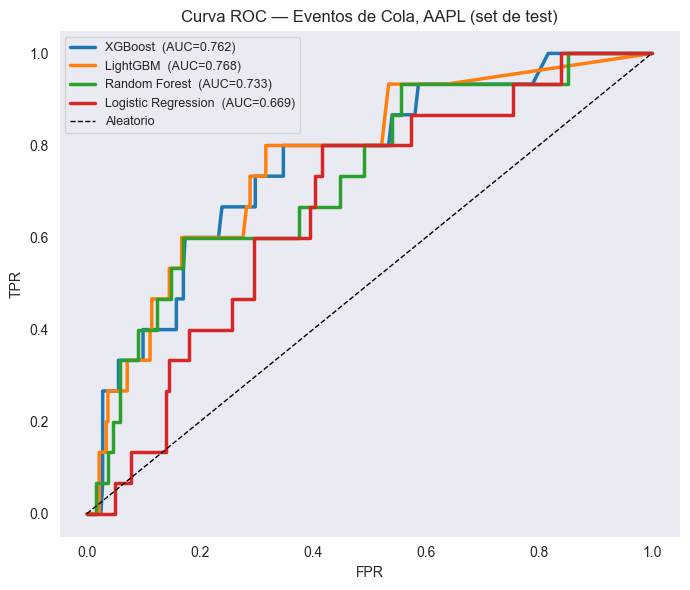

LightGBM              0.7676
XGBoost               0.7618
Random Forest         0.7325
Logistic Regression   0.6692
Name: AUC-ROC test, dtype: float64


In [5]:
xgb_clf = xgb.XGBClassifier(
    n_estimators=1000, learning_rate=0.03, max_depth=3,
    subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0,
    eval_metric="auc", early_stopping_rounds=50, random_state=42
)
xgb_clf.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

lgb_clf = lgb.LGBMClassifier(
    n_estimators=1000, learning_rate=0.03, num_leaves=7,
    subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0,
    random_state=42, verbosity=-1
)
lgb_clf.fit(X_train, y_train, eval_set=[(X_val, y_val)], eval_metric="auc",
            callbacks=[lgb.early_stopping(50, verbose=False)])

rf_clf = RandomForestClassifier(n_estimators=300, max_features="sqrt", min_samples_leaf=10,
                                 random_state=42, n_jobs=-1).fit(X_train, y_train)
lr_clf = LogisticRegression(max_iter=1000, random_state=42).fit(X_train, y_train)

modelos = {
    "XGBoost":              (xgb_clf, xgb_clf.predict_proba(X_test)[:, 1]),
    "LightGBM":              (lgb_clf, lgb_clf.predict_proba(X_test)[:, 1]),
    "Random Forest":        (rf_clf,  rf_clf.predict_proba(X_test)[:, 1]),
    "Logistic Regression":  (lr_clf,  lr_clf.predict_proba(X_test)[:, 1]),
}

print(f"XGBoost  detuvo en la ronda: {xgb_clf.best_iteration}")
print(f"LightGBM detuvo en la ronda: {lgb_clf.best_iteration_}")
print()

fig, ax = plt.subplots(figsize=(7, 6))
resultados = {}
for name, (model, proba) in modelos.items():
    auc = roc_auc_score(y_test, proba)
    resultados[name] = auc
    fpr, tpr, _ = roc_curve(y_test, proba)
    ax.plot(fpr, tpr, lw=2.5, label=f"{name}  (AUC={auc:.3f})")
ax.plot([0, 1], [0, 1], "k--", lw=1, label="Aleatorio")
ax.set_xlabel("FPR"); ax.set_ylabel("TPR")
ax.set_title(f"Curva ROC — Eventos de Cola, {TICKER} (set de test)")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

df_resultados = pd.Series(resultados, name="AUC-ROC test").sort_values(ascending=False)
print(df_resultados.round(4))

**Interpretación:** los tres ensembles de árboles (XGBoost, LightGBM, Random Forest) superan claramente a Logistic Regression — el evento de cola depende de interacciones no lineales entre volatilidad, momentum y RSI que un modelo lineal no puede capturar. Entre los tres ensembles el orden puede variar según la semilla y el activo — **boosting no gana automáticamente**; su ventaja está en el *control fino* que ofrece vía `learning_rate`, regularización y restricciones (monótonas, por ejemplo), no en una superioridad garantizada de AUC. Nota también que `LightGBM` suele detenerse en muy pocas rondas de *early stopping* cuando el set de validación es chico y el evento es raro (~5% de tasa base) — el AUC de validación con pocas observaciones positivas es una métrica ruidosa, algo a tener en cuenta al decidir el tamaño del set de validación en producción.

## 🛠️ **`XGBoost dentro de un Pipeline de scikit-learn`**

Hasta ahora entrenamos `xgb_clf` directamente sobre arrays ya limpios. En producción esto casi nunca ocurre así: hay que imputar missing values, y típicamente se busca la combinación de hiperparámetros vía validación cruzada — todo encapsulado en un único objeto para evitar *data leakage* (que estadísticas de preprocesamiento se calculen usando datos que el modelo no debería ver todavía) y para simplificar el despliegue (un solo objeto serializable con `joblib`, no un preprocesador y un modelo por separado).

Un `Pipeline` de sklearn encadena estos pasos y expone la misma interfaz `.fit()` / `.predict_proba()` que cualquier estimador individual. Combinado con `GridSearchCV`, la búsqueda de hiperparámetros se hace *dentro* de cada fold de validación cruzada — el imputer/scaler se ajustan solo con el fold de entrenamiento en cada iteración, nunca con el fold de validación.

Como los datos son series de tiempo, no podemos usar `KFold` estándar (mezclaría información futura hacia el pasado). `TimeSeriesSplit` genera folds respetando el orden temporal: cada fold de validación queda estrictamente después de su fold de entrenamiento (ventana expansiva).

In [6]:
pipe_xgb = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("clf", xgb.XGBClassifier(eval_metric="auc", random_state=42)),
])

param_grid = {
    "clf__n_estimators": [200, 400],
    "clf__max_depth": [2, 3, 4],
    "clf__learning_rate": [0.03, 0.1],
}

X_train_full = np.vstack([X_train, X_val])
y_train_full = np.concatenate([y_train, y_val])

tscv = TimeSeriesSplit(n_splits=5)
grid_xgb = GridSearchCV(pipe_xgb, param_grid, scoring="roc_auc", cv=tscv, n_jobs=-1)
grid_xgb.fit(X_train_full, y_train_full)

pred_pipe = grid_xgb.predict_proba(X_test)[:, 1]

print(f"Mejores hiperparámetros: {grid_xgb.best_params_}")
print(f"AUC promedio en CV (TimeSeriesSplit, 5 folds): {grid_xgb.best_score_:.4f}")
print(f"AUC en test:                                   {roc_auc_score(y_test, pred_pipe):.4f}")

Mejores hiperparámetros: {'clf__learning_rate': 0.03, 'clf__max_depth': 2, 'clf__n_estimators': 200}
AUC promedio en CV (TimeSeriesSplit, 5 folds): 0.6543
AUC en test:                                   0.7308


**Interpretación:** `GridSearchCV` prueba cada combinación de `n_estimators`/`max_depth`/`learning_rate` sobre los 5 folds de `TimeSeriesSplit` y se queda con la de mejor AUC promedio — sin que ninguna estadística de escalado o imputación "vea" el fold de validación de turno. Este enfoque (Pipeline + CV temporal) y el enfoque anterior (un solo modelo con *early stopping* sobre un único set de validación) responden a necesidades distintas: *early stopping* es más rápido y es lo estándar cuando el modelo se re-entrena frecuentemente en producción (por ejemplo, diariamente); la búsqueda con `TimeSeriesSplit` es más robusta (promedia sobre varias ventanas temporales) pero más costosa computacionalmente, y tiene más sentido para una búsqueda de hiperparámetros que se corre con poca frecuencia (por ejemplo, trimestralmente) y cuyo resultado (`grid_xgb.best_estimator_`) luego se re-entrena con *early stopping* para el día a día. El objeto `grid_xgb.best_estimator_` es un `Pipeline` completo — imputer, scaler y modelo — listo para serializar con `joblib.dump()` y desplegar como una sola unidad.

## 📊 **`Feature Importance en XGBoost: Weight, Gain y Cover`**

En la sesión 8 vimos que Random Forest reporta un único tipo de importancia (MDI, sesgada hacia features de alta cardinalidad). XGBoost, al llevar la cuenta exacta de cada split, expone tres métricas distintas para el mismo modelo ya entrenado (`xgb_clf`, de la sección de comparación):

- **Weight:** cuántas veces se usó el feature para partir, sumando sobre todos los árboles. Sufre el mismo sesgo que MDI hacia features con muchos valores únicos (más oportunidades de split).
- **Gain:** la mejora promedio en la función objetivo que aportan los splits que usan ese feature. Es la métrica más informativa para comparar la *calidad* de un feature, no solo su frecuencia de uso.
- **Cover:** el número promedio de observaciones afectadas por los splits de ese feature (aproximado por la suma de Hessianos en esas hojas).

Esto da una primera lectura de qué variables domina el modelo, sin entrar en la teoría de valores de Shapley ni en explicaciones por-predicción-individual — esa profundidad de interpretabilidad (SHAP) se cubre en una sesión dedicada más adelante en el curso.

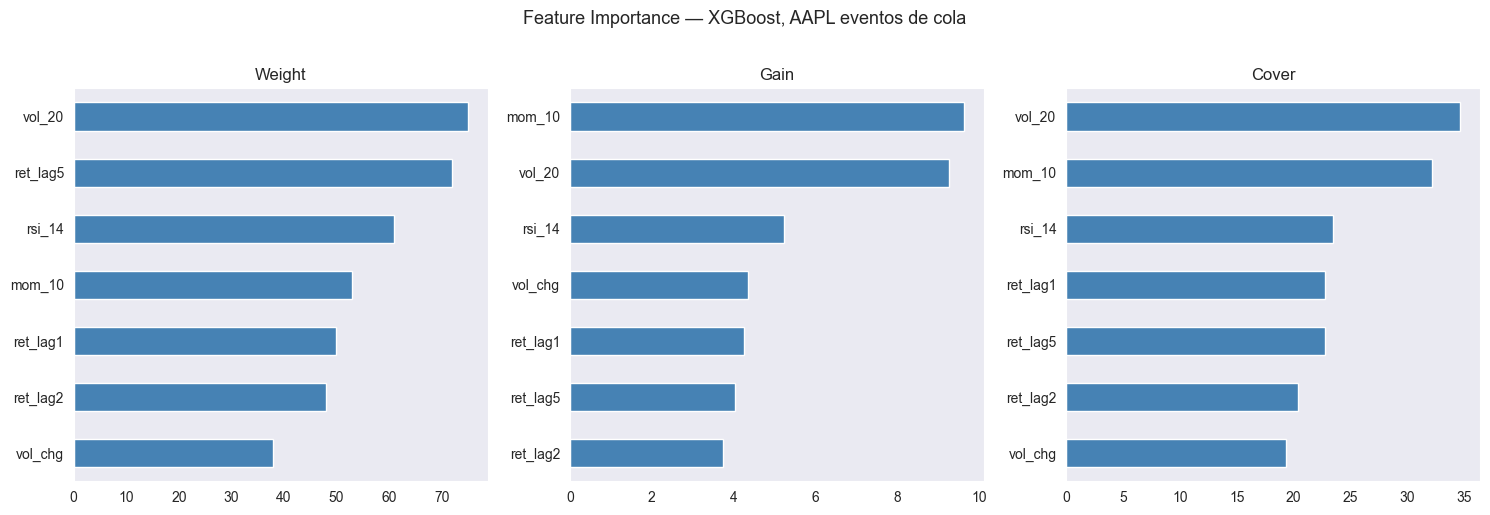

          Weight   Gain   Cover
mom_10   53.0000 9.6398 32.2080
vol_20   75.0000 9.2694 34.6607
rsi_14   61.0000 5.2425 23.4749
vol_chg  38.0000 4.3515 19.2990
ret_lag1 50.0000 4.2551 22.8051
ret_lag5 72.0000 4.0449 22.7589
ret_lag2 48.0000 3.7489 20.4309


In [7]:
importance_types = ["weight", "gain", "cover"]
imp_df = pd.DataFrame({
    imp_type: pd.Series(xgb_clf.get_booster().get_score(importance_type=imp_type))
    for imp_type in importance_types
})
imp_df.index = [FEATURES[int(f[1:])] for f in imp_df.index]   # f0, f1, ... -> nombre real
imp_df = imp_df.reindex(FEATURES).fillna(0.0)
imp_df.columns = ["Weight", "Gain", "Cover"]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, col in zip(axes, imp_df.columns):
    imp_df[col].sort_values().plot.barh(ax=ax, color="steelblue")
    ax.set_title(col)
plt.suptitle(f"Feature Importance — XGBoost, {TICKER} eventos de cola", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(imp_df.sort_values("Gain", ascending=False).round(4))

**Interpretación:** compara el orden de las tres columnas — si `Weight` y `Gain` rankean distinto a un feature, significa que se usa poco pero cuando se usa aporta mucho (alta calidad, baja frecuencia) o lo contrario (se usa mucho pero cada split aporta poco). En eventos de cola suele dominar `vol_20` en `Gain` (splits sobre volatilidad reciente separan bien la clase minoritaria) aunque no necesariamente sea el feature más *usado* (`Weight`) — la asimetría entre ambas columnas es justamente la señal de que mirar una sola métrica de importancia puede llevar a conclusiones distintas. `Cover` complementa esto mostrando cuántas observaciones caen bajo cada split, útil para detectar features que solo importan para un segmento chico de la muestra.

## ⚠️ **`Sensibilidad a Ruido de Etiquetas: Boosting vs Bagging`**

### Por qué Boosting es, en teoría, más frágil

Bagging diluye el efecto de cualquier observación individual: cada árbol solo la ve con probabilidad ${\approx}63\%$ (su bootstrap), y el resto de los árboles ni siquiera la consideran. Boosting, en cambio, ajusta **secuencialmente** al residuo — si una observación tiene una etiqueta corrupta (ruido), el árbol que peor la predice genera un gradiente grande para ella, y el **siguiente** árbol intenta específicamente corregir ese error. Si el ruido persiste en el residuo, boosting puede dedicar varias rondas a perseguir un punto que en realidad está mal etiquetado.

La celda siguiente contamina una fracción creciente de las etiquetas de **entrenamiento** (invirtiendo la clase al azar) y mide cómo se degrada el AUC de test — sobre un test **limpio** — para Random Forest vs XGBoost. Repetimos cada nivel de ruido con 8 semillas distintas para promediar el ruido propio de estimar AUC con una tasa base de ~5%.

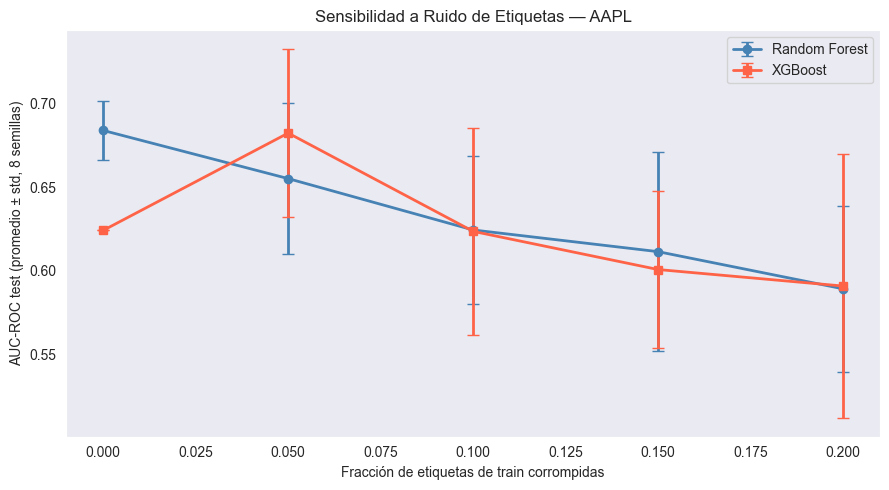

 noise_frac  auc_rf_mean  auc_rf_std  auc_gbm_mean  auc_gbm_std
     0.0000       0.6841      0.0177        0.6242       0.0000
     0.0500       0.6552      0.0453        0.6825       0.0504
     0.1000       0.6245      0.0443        0.6236       0.0622
     0.1500       0.6115      0.0596        0.6008       0.0468
     0.2000       0.5892      0.0496        0.5909       0.0792


In [8]:
noise_levels = [0.0, 0.05, 0.10, 0.15, 0.20]
n_repeats = 8

noise_results = []
for noise_frac in noise_levels:
    aucs_rf, aucs_gbm = [], []
    for rep in range(n_repeats):
        rng = np.random.RandomState(rep)
        y_train_noisy = y_train.copy()
        n_flip = int(noise_frac * len(y_train))
        flip_idx = rng.choice(len(y_train), size=n_flip, replace=False)
        y_train_noisy[flip_idx] = 1 - y_train_noisy[flip_idx]

        rf_n = RandomForestClassifier(n_estimators=200, max_features="sqrt",
                                       random_state=rep, n_jobs=-1).fit(X_train, y_train_noisy)
        gbm_n = xgb.XGBClassifier(n_estimators=200, learning_rate=0.1, max_depth=3,
                                   random_state=rep).fit(X_train, y_train_noisy)

        aucs_rf.append(roc_auc_score(y_test, rf_n.predict_proba(X_test)[:, 1]))
        aucs_gbm.append(roc_auc_score(y_test, gbm_n.predict_proba(X_test)[:, 1]))

    noise_results.append({
        "noise_frac": noise_frac,
        "auc_rf_mean": np.mean(aucs_rf), "auc_rf_std": np.std(aucs_rf),
        "auc_gbm_mean": np.mean(aucs_gbm), "auc_gbm_std": np.std(aucs_gbm),
    })

df_noise = pd.DataFrame(noise_results)

fig, ax = plt.subplots(figsize=(9, 5))
ax.errorbar(df_noise["noise_frac"], df_noise["auc_rf_mean"], yerr=df_noise["auc_rf_std"],
            marker="o", capsize=4, lw=2, color="steelblue", label="Random Forest")
ax.errorbar(df_noise["noise_frac"], df_noise["auc_gbm_mean"], yerr=df_noise["auc_gbm_std"],
            marker="s", capsize=4, lw=2, color="tomato", label="XGBoost")
ax.set_xlabel("Fracción de etiquetas de train corrompidas")
ax.set_ylabel("AUC-ROC test (promedio ± std, 8 semillas)")
ax.set_title(f"Sensibilidad a Ruido de Etiquetas — {TICKER}")
ax.legend()
plt.tight_layout()
plt.show()

print(df_noise.round(4).to_string(index=False))

**Interpretación:** en promedio, ambos modelos se degradan de forma parecida al aumentar el ruido de etiquetas — la ventaja de boosting no desaparece dramáticamente en el promedio. Sin embargo, mira la **desviación estándar** entre semillas: la de XGBoost suele ser considerablemente mayor que la de Random Forest en los niveles de ruido intermedios. Esto es el efecto predicho por la teoría, pero manifestado como **inestabilidad** más que como degradación pura del promedio: qué observaciones específicas quedaron corrompidas importa mucho más para boosting (porque el orden secuencial amplifica el efecto de esas observaciones puntuales) que para Random Forest (donde el bootstrap ya diluye cualquier punto individual). En la práctica: si sospechas etiquetas ruidosas (común en credit scoring con default reportado con rezago, o en labels de eventos de mercado ambiguos), Random Forest es una opción más robusta por defecto, y si usas boosting, vale la pena aumentar `min_child_weight`/`min_data_in_leaf` y $\lambda$ para amortiguar el efecto.

## 🚧 **`Boosting Tampoco Extrapola`**

Boosting sigue construido sobre árboles de decisión — cada hoja predice un valor constante determinado por las observaciones de entrenamiento que cayeron en esa región. Esto significa que **hereda exactamente la misma limitación de extrapolación** que vimos para Random Forest en la sesión 8: sin importar cuántas rondas de boosting agregues, la predicción nunca puede superar el rango de $y$ visto en entrenamiento.

Repetimos la demostración de la sesión 8 (volatilidad realizada de `TICKER`, entrenando con datos previos a 2020 y evaluando en la ventana de la crisis COVID-19, enero–julio 2020), agregando XGBoost a la comparación RF vs Ridge.

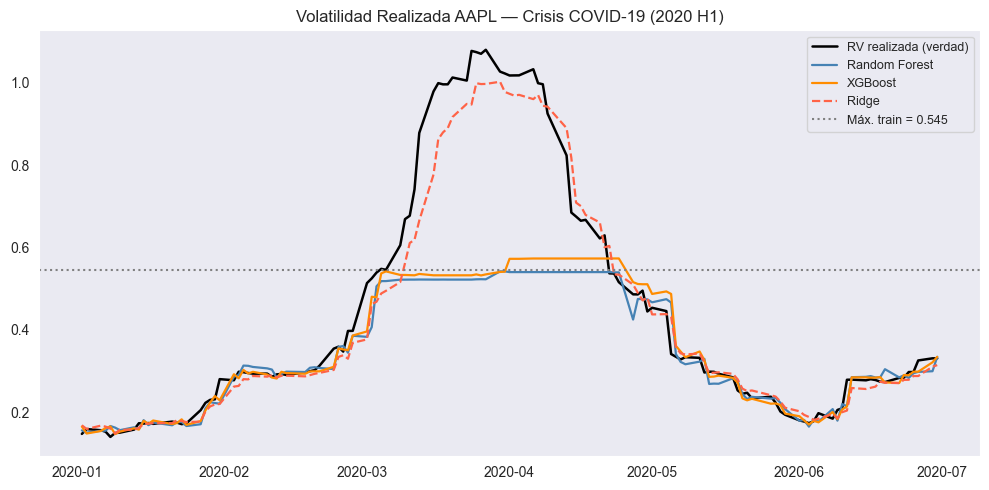

Máximo en train (< 2020):        0.5449
Máximo real en test (COVID):      1.0795
Máximo predicho — Random Forest:  0.5420
Máximo predicho — XGBoost:        0.5734
Máximo predicho — Ridge:          1.0020

RMSE — Random Forest: 0.2002
RMSE — XGBoost:       0.1922
RMSE — Ridge:         0.0524


In [9]:
rv20 = ret.rolling(20).std() * np.sqrt(252)
feat_rv = pd.DataFrame(index=raw.index)
feat_rv["rv_lag1"]  = rv20.shift(1)
feat_rv["rv_lag5"]  = rv20.shift(5)
feat_rv["rv_lag22"] = rv20.shift(22)
feat_rv["target_rv"] = rv20
feat_rv = feat_rv.dropna()

RV_FEATURES = ["rv_lag1", "rv_lag5", "rv_lag22"]
train_mask_rv = feat_rv.index < "2020-01-01"
test_mask_rv  = (feat_rv.index >= "2020-01-01") & (feat_rv.index < "2020-07-01")

X_train_rv = feat_rv.loc[train_mask_rv, RV_FEATURES].values
y_train_rv = feat_rv.loc[train_mask_rv, "target_rv"].values
X_test_rv  = feat_rv.loc[test_mask_rv,  RV_FEATURES].values
y_test_rv  = feat_rv.loc[test_mask_rv,  "target_rv"].values
dates_test_rv = feat_rv.loc[test_mask_rv].index

rf_v   = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1).fit(X_train_rv, y_train_rv)
xgb_v  = xgb.XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=3, random_state=42).fit(X_train_rv, y_train_rv)
ridge_v = Ridge(alpha=1.0).fit(X_train_rv, y_train_rv)

pred_rf_v, pred_xgb_v, pred_ridge_v = rf_v.predict(X_test_rv), xgb_v.predict(X_test_rv), ridge_v.predict(X_test_rv)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(dates_test_rv, y_test_rv, "k-", lw=1.8, label="RV realizada (verdad)")
ax.plot(dates_test_rv, pred_rf_v, color="steelblue", lw=1.6, label="Random Forest")
ax.plot(dates_test_rv, pred_xgb_v, color="darkorange", lw=1.6, label="XGBoost")
ax.plot(dates_test_rv, pred_ridge_v, color="tomato", lw=1.6, ls="--", label="Ridge")
ax.axhline(y_train_rv.max(), color="gray", ls=":", lw=1.5, label=f"Máx. train = {y_train_rv.max():.3f}")
ax.set_title(f"Volatilidad Realizada {TICKER} — Crisis COVID-19 (2020 H1)")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f"Máximo en train (< 2020):        {y_train_rv.max():.4f}")
print(f"Máximo real en test (COVID):      {y_test_rv.max():.4f}")
print(f"Máximo predicho — Random Forest:  {pred_rf_v.max():.4f}")
print(f"Máximo predicho — XGBoost:        {pred_xgb_v.max():.4f}")
print(f"Máximo predicho — Ridge:          {pred_ridge_v.max():.4f}")
print()
print(f"RMSE — Random Forest: {mean_squared_error(y_test_rv, pred_rf_v)**0.5:.4f}")
print(f"RMSE — XGBoost:       {mean_squared_error(y_test_rv, pred_xgb_v)**0.5:.4f}")
print(f"RMSE — Ridge:         {mean_squared_error(y_test_rv, pred_ridge_v)**0.5:.4f}")

**Interpretación:** tanto Random Forest como XGBoost quedan acotados por el máximo visto en entrenamiento (línea gris punteada) — ninguno de los dos ensembles de árboles logra anticipar la magnitud real del pico de volatilidad de marzo 2020, y ambos muestran RMSE mucho más alto que Ridge en esta ventana. Ridge, al ser lineal, sí puede proyectar más allá del rango histórico (para bien, como aquí, o potencialmente para mal si la relación no es realmente lineal fuera de rango). La lección de la sesión 8 se mantiene sin cambios al pasar de bagging a boosting: **ningún modelo basado en árboles decision-constant-por-región puede sustituir a un modelo con capacidad de extrapolación en un régimen genuinamente inédito**. En producción, esto argumenta por monitorear cuándo los features de entrada se acercan o superan el rango histórico de entrenamiento (flag de "out-of-distribution"), independientemente de si el modelo es RF o boosting.

## 📐 **`Restricciones Monótonas: Boosting para Cumplimiento Regulatorio`**

### El problema

En scoring crediticio, un modelo de árboles puede aprender relaciones **no monótonas** por sobreajuste local: por ejemplo, que la probabilidad de default *baje* levemente para un rango específico de DTI (debt-to-income) alto, simplemente porque en esa región puntual de la muestra de entrenamiento hubo pocos defaults por azar. Esto es indefendible ante un regulador: económicamente, mayor DTI debería implicar mayor (o igual) riesgo de default, nunca menor.

XGBoost y LightGBM permiten imponer **restricciones de monotonía** directamente en la construcción del árbol: al evaluar un split candidato, se descartan aquellos que producirían una relación no monótona entre un feature y la predicción, para los features marcados (`monotone_constraints=(1, 0, -1, ...)`: $1$ = monótono creciente, $-1$ = decreciente, $0$ = sin restricción).

Esto es exclusivo de boosting entre los métodos vistos en el curso — Random Forest no ofrece este control nativamente.

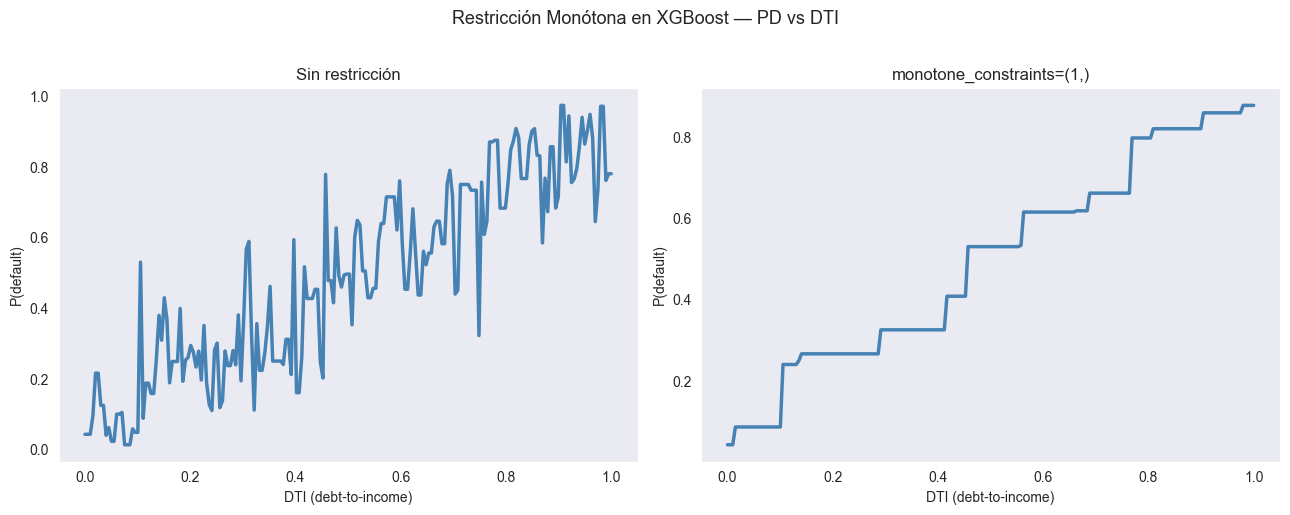

¿Curva sin restricción es monótona creciente?  False
¿Curva con restricción es monótona creciente?  True


In [10]:
np.random.seed(1)
n_mono = 2000
dti_mono = np.random.uniform(0, 1, n_mono)
noise_mono = np.random.normal(0, 0.3, n_mono)
logit_mono = -2 + 4 * dti_mono + noise_mono
p_mono = 1 / (1 + np.exp(-logit_mono))
default_mono = (np.random.rand(n_mono) < p_mono).astype(int)
X_mono = dti_mono.reshape(-1, 1)

xgb_free = xgb.XGBClassifier(n_estimators=200, max_depth=3, random_state=42).fit(X_mono, default_mono)
xgb_mono = xgb.XGBClassifier(n_estimators=200, max_depth=3, random_state=42,
                              monotone_constraints=(1,)).fit(X_mono, default_mono)

grid_dti = np.linspace(0, 1, 200).reshape(-1, 1)
pred_free = xgb_free.predict_proba(grid_dti)[:, 1]
pred_mono = xgb_mono.predict_proba(grid_dti)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, pred, title in zip(axes, [pred_free, pred_mono],
                           ["Sin restricción", "monotone_constraints=(1,)"]):
    ax.plot(grid_dti, pred, color="steelblue", lw=2.5)
    ax.set_xlabel("DTI (debt-to-income)"); ax.set_ylabel("P(default)")
    ax.set_title(title)
plt.suptitle("Restricción Monótona en XGBoost — PD vs DTI", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

is_monotonic_free = np.all(np.diff(pred_free) >= -1e-9)
is_monotonic_mono = np.all(np.diff(pred_mono) >= -1e-9)
print(f"¿Curva sin restricción es monótona creciente?  {is_monotonic_free}")
print(f"¿Curva con restricción es monótona creciente?  {is_monotonic_mono}")

**Interpretación:** el modelo sin restricción puede mostrar pequeñas inversiones locales (la PD baja levemente en algún tramo de DTI) puramente por ruido muestral — inofensivo para el AUC agregado, pero problemático si un analista de riesgo o un regulador audita la curva feature-por-feature. El modelo con `monotone_constraints=(1,)` fuerza que cada split respete la dirección económica esperada, produciendo una curva monótona por construcción, al costo de un poder predictivo marginalmente menor si la relación real tuviera micro-reversiones genuinas (raro en la práctica para variables como DTI o score de crédito). Esta es una herramienta que vale la pena tener presente en cualquier modelo de boosting destinado a un entorno regulado.

## 🧭 **`Resumen`**

### Lo que construimos en esta sesión

```
Gradient Boosting   ──► suma aditiva de arboles debiles, cada uno ajustado
                        al pseudo-residuo del ensemble acumulado (↓ sesgo)
       ↓
XGBoost             ──► + regularizacion L1/L2 explicita, aproximacion de
                        2do orden (gradiente + Hessiano), shrinkage, subsampling
       ↓
LightGBM            ──► + crecimiento leaf-wise, histogramas, GOSS
                        (mas rapido, mas propenso a overfit sin cuidado)
```

### Contraste con Random Forest (Sesión 8)

| | Random Forest | Boosting (XGBoost/LightGBM) |
|---|---|---|
| Mecanismo de reducción de error | Promedio de árboles independientes (↓ varianza) | Corrección secuencial de residuos (↓ sesgo) |
| `n_estimators` alto | Nunca sobreajusta | **Sobreajusta** — requiere early stopping |
| Sensibilidad a ruido de etiquetas | Baja / estable | Más inestable entre semillas |
| Feature importance | MDI (sesgada) / Permutation | Weight / Gain / Cover (nativas de XGBoost) |
| Búsqueda de hiperparámetros en producción | Grid/Random search estándar | Pipeline + `TimeSeriesSplit` para CV, luego *early stopping* para refresh |
| Extrapolación fuera del rango de train | No | Tampoco — misma limitación estructural de los árboles |
| Restricciones monótonas nativas | No | Sí (`monotone_constraints`) |